<a href="https://colab.research.google.com/github/Hassaan-Waheed/Deep-Learning/blob/master/CIFR_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
%%writefile model.py
import torch
import torch.nn as nn
import torch.nn.functional as F

class CIFAR_VGG(nn.Module):
    def __init__(self):
        super(CIFAR_VGG, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        # Dropout layers: 0.25 for conv, 0.5 for fully connected
        self.dropout_conv = nn.Dropout2d(0.25)
        self.dropout_fc = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

Overwriting model.py


In [7]:
%%writefile data_setup.py
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

def get_loaders(batch_size=64):
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Colab storage is temporary, so we save to /content/data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

    classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    return train_loader, test_loader, classes

def visualize_samples(loader, classes):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    img_grid = torchvision.utils.make_grid(images[:4]) / 2 + 0.5
    plt.imshow(np.transpose(img_grid.numpy(), (1, 2, 0)))
    plt.title(' '.join(f'{classes[labels[j]]}' for j in range(4)))
    plt.show()

Overwriting data_setup.py


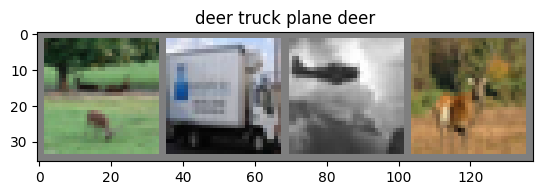

In [8]:
from data_setup import get_loaders, visualize_samples

# This actually runs the code you just saved
train_loader, test_loader, classes = get_loaders(batch_size=64)
visualize_samples(train_loader, classes)

In [10]:
import torch
import torch.optim as optim
import torch.nn as nn
from model import CIFAR_VGG
from data_setup import get_loaders, visualize_samples

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, test_loader, classes = get_loaders(batch_size=128)
model = CIFAR_VGG().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3)

# Early Stopping Parameters
patience = 5
best_acc = 0.0
counter = 0

def train():
    global best_acc, counter
    print(f"🚀 Training started on {device}...")

    for epoch in range(25):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/25] - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.2f}%")

        scheduler.step(accuracy) # Moved here after accuracy is computed

        # Early Stopping & Saving Logic
        if accuracy > best_acc:
            best_acc = accuracy
            torch.save(model.state_dict(), 'cifar_vgg_best.pth')
            print(f"--- 💾 Model saved (Best Accuracy: {best_acc:.2f}%) ---")
            counter = 0 # Reset patience
        else:
            counter += 1
            if counter >= patience:
                print(f"🛑 Early stopping triggered. No improvement for {patience} epochs.")
                break

    print(f"✅ Training Complete. Best Accuracy: {best_acc:.2f}%")

train()

🚀 Training started on cuda...
Epoch [1/25] - Loss: 1.6742 - Accuracy: 54.25%
--- 💾 Model saved (Best Accuracy: 54.25%) ---
Epoch [2/25] - Loss: 1.4199 - Accuracy: 58.68%
--- 💾 Model saved (Best Accuracy: 58.68%) ---
Epoch [3/25] - Loss: 1.3029 - Accuracy: 62.99%
--- 💾 Model saved (Best Accuracy: 62.99%) ---
Epoch [4/25] - Loss: 1.2217 - Accuracy: 65.35%
--- 💾 Model saved (Best Accuracy: 65.35%) ---
Epoch [5/25] - Loss: 1.1572 - Accuracy: 66.24%
--- 💾 Model saved (Best Accuracy: 66.24%) ---
Epoch [6/25] - Loss: 1.1111 - Accuracy: 67.58%
--- 💾 Model saved (Best Accuracy: 67.58%) ---
Epoch [7/25] - Loss: 1.0673 - Accuracy: 68.87%
--- 💾 Model saved (Best Accuracy: 68.87%) ---
Epoch [8/25] - Loss: 1.0337 - Accuracy: 69.81%
--- 💾 Model saved (Best Accuracy: 69.81%) ---
Epoch [9/25] - Loss: 1.0012 - Accuracy: 70.26%
--- 💾 Model saved (Best Accuracy: 70.26%) ---
Epoch [10/25] - Loss: 0.9746 - Accuracy: 71.29%
--- 💾 Model saved (Best Accuracy: 71.29%) ---
Epoch [11/25] - Loss: 0.9511 - Accuracy